**<center><font size=8>Student Performance Prediction Using Machine Learning</center></font>**

<center><p float="center">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcThy6yW7h-4xRImPp44vkzfc1hWOKoIZA6MTyvCEvq-ccwqrymL4WT8Drx0&s=10" height=400 width=750>
</p></center>


This notebook details a machine learning project aimed at predicting student exam scores based on various factors. It covers the complete lifecycle from data loading and exploration to model building, evaluation, and deployment.

# 1. Import Libraries

This section imports all necessary Python libraries required for data manipulation, visualization, and machine learning tasks throughout the notebook.

This cell imports essential libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`), and machine learning (`sklearn`). `sklearn` components include `train_test_split` for data partitioning, `LinearRegression` for model building, `mean_absolute_error`, `mean_squared_error`, `r2_score` for model evaluation, and `LabelEncoder` for categorical feature encoding.

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder


# 2.Mount Google Drive

The dataset is stored in Google Drive. This step connects Google Drive with Google Colab so that the dataset can be accessed.****

This code block imports the `drive` module from `google.colab` and mounts your Google Drive to the Colab environment, allowing access to files stored in your Drive, such as the dataset used in this project.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Load Dataset

Here, we load the dataset into a pandas DataFrame, which is the primary data structure for data analysis in Python. The data is retrieved from a specified path in Google Drive.

This cell utilizes the `pandas` library to read the CSV file, which is compressed in a zip archive, directly from the specified path in Google Drive into a DataFrame named `df`. This DataFrame will be the primary object for all subsequent data operations.

In [3]:
# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/my own notebook/archive (1).zip")

# 4.Data overview

This section provides an initial overview of the dataset. We'll examine the first few rows, check its dimensions, review data types, and generate a statistical summary to understand its basic characteristics and identify potential issues like missing values or incorrect data types.

## 4.1 Display Dataset

This command displays the first 5 rows of the DataFrame, providing a quick glance at the dataset's structure, column names, and initial values, which helps in understanding the data's format.

In [4]:
#display first 5rows
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 4.2 Dataset Shape

This cell returns a tuple representing the dimensions of the DataFrame (number of rows, number of columns), giving a concise summary of the dataset's size.

In [5]:
#check number of rows and columns
df.shape

(6607, 20)

## 4.3 Dataset information

The `info()` method prints a concise summary of the DataFrame, including the number of entries, number of columns, non-null values for each column, and data types. This helps identify columns with missing data and understand memory usage.

In [6]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

## 4.4 Statistical Summary

This command generates descriptive statistics that summarize the central tendency, dispersion, and shape of the dataset's distribution for numerical columns. It provides insights into the data's range, mean, standard deviation, and quartiles.

In [7]:
#statistical summary
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


# 5.Exploratory Data Analysis

EDA involves analyzing the dataset to discover patterns, spot anomalies, test hypotheses, and check assumptions with the help of summary statistics and graphical representations. In this section, we specifically look at the correlation between numerical features using a heatmap.

## 5.1 Missing values

This cell calculates and displays the count of missing values for each column in the DataFrame. It's a critical step to identify which columns require imputation or handling of missing data.

In [8]:
#check missing values
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


## 5.2 Duplicate values

This command checks for and counts duplicate rows in the DataFrame. Identifying duplicates is important for data quality, as they can bias analysis and model training.

In [9]:
#check duplicate rows
df.duplicated().sum()

np.int64(0)

## 5.3 Data types

This cell displays the data type of each column in the DataFrame. Understanding data types is essential for proper data manipulation and for ensuring compatibility with machine learning algorithms.

In [10]:
# check data types
df.dtypes

,0
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


## 5.4 Correlation Analysis





This code calculates the pairwise correlation between numerical columns in the DataFrame. Correlation values indicate the strength and direction of a linear relationship between two variables.

In [11]:
# Correlation between numerical columns
correlation = df.corr(numeric_only=True)

correlation

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624,0.445455
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435,0.581072
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378,-0.017022
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274,0.175079
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733,0.156525
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000,0.027824
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.156525,0.027824,1.000000


## 5.5 Correlation Heapmap

This cell generates a heatmap to visualize the correlation matrix. A heatmap provides a clear, color-coded representation of correlation coefficients, making it easier to identify highly correlated features.

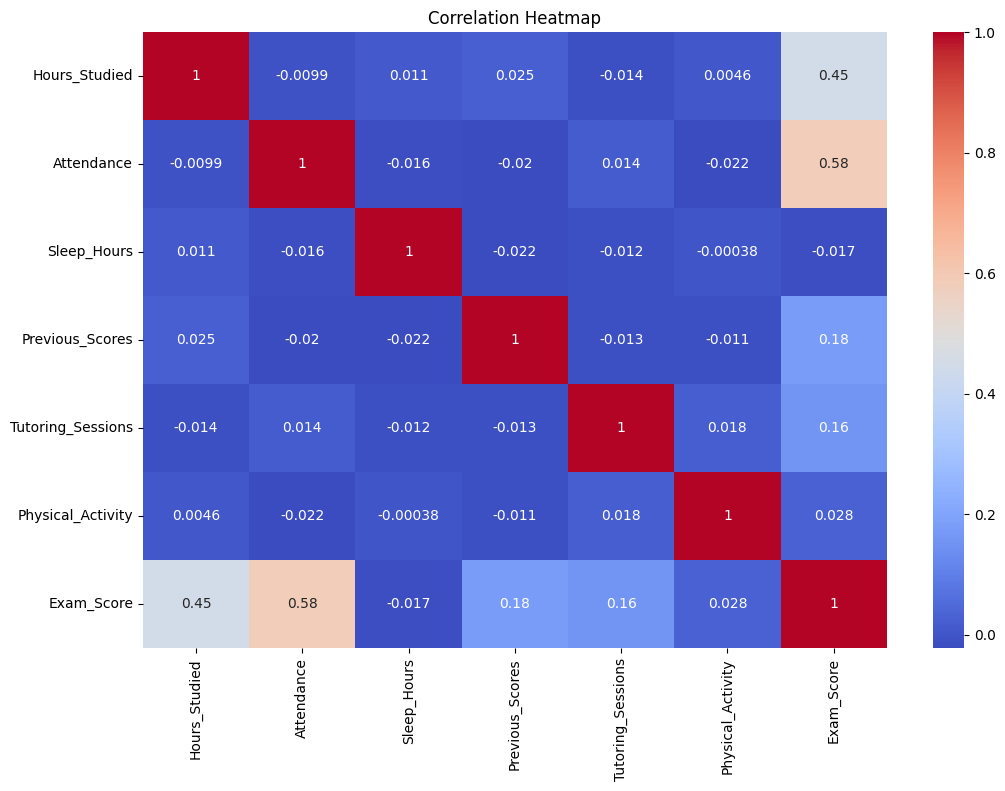

In [12]:
# Correlation Heatmap
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 6. Data Preprocessing

Data preprocessing is a crucial step in preparing the raw data for machine learning models. This involves handling missing values to ensure data completeness and encoding categorical variables into numerical formats, as most machine learning algorithms require numerical input.

## 6.1 Handle Missing Values


Before proceeding with handling missing values, this cell re-confirms the count of missing values per column, ensuring that the latest state of the DataFrame is considered for imputation.

In [13]:
# Display missing values
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [14]:
# Fill missing values with mode (most frequent value)
df.fillna(df.mode().iloc[0], inplace=True)

This command fills all missing (NaN) values in the DataFrame with the mode (most frequent value) of their respective columns. This is a common strategy for handling missing categorical or slightly skewed numerical data.

## 6.2 Label Encoding

This cell initializes an instance of `LabelEncoder` from `sklearn.preprocessing`. `LabelEncoder` is used to convert categorical labels into numerical format, which is required by most machine learning algorithms.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHo...er(handle_unknown='ignore'))]),
                                                  Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

# 7.Feature Selection

In this cell, the features (input variables, `X`) are separated from the target variable (output variable, `y`). The 'Exam_Score' column is designated as the target, and all other columns are used as features for the model.

In [16]:
# Features (Input)
X = df.drop("Exam_Score", axis=1)

# Target (Output)
y = df["Exam_Score"]

# 8. Train-Test Split

Before training a model, the dataset is typically split into training and testing sets. The training set is used to teach the model, and the test set is used to evaluate its performance on unseen data, helping to assess its generalization ability.

This cell splits the dataset into training and testing sets. `X_train` and `y_train` are used to train the model, while `X_test` and `y_test` are reserved for evaluating the model's performance on unseen data. A test size of 20% and `random_state=42` ensure reproducibility.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 9. Model Building

This cell initializes a `LinearRegression` model object. Linear Regression is a fundamental supervised learning algorithm used for predicting a continuous target variable by fitting a linear equation to the observed data.

In [18]:
# Create Linear Regression Model
model = LinearRegression()

This command trains the `LinearRegression` model using the training features (`X_train`) and their corresponding target values (`y_train`). During this process, the model learns the relationships between the features and the target variable.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

# Re-identify categorical and numerical columns from X_train
categorical_cols = X_train.select_dtypes(include="object").columns
numeric_cols = X_train.select_dtypes(exclude="object").columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Re-create the full pipeline to ensure proper preprocessing
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train the model using the training data
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHo...er(handle_unknown='ignore'))]),
                                                  Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

After training, this cell uses the trained model to make predictions on the unseen test features (`X_test`). The `y_pred` variable will store the model's predicted exam scores for the test set.

## 10. Prediction

After the model has been trained, it is used to make predictions on the test set. These predictions will then be compared against the actual values to evaluate the model's accuracy and performance.

This cell calculates and prints three common regression evaluation metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2 Score). These metrics quantify the difference between the actual test scores (`y_test`) and the predicted scores (`y_pred`), providing insights into the model's accuracy and fit.

In [20]:
# Predict using test data
y_pred = model.predict(X_test)

## 11. Model Evaluation

Model evaluation is performed to assess how well the trained model performs. Common metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2 Score) are used to quantify the prediction accuracy and overall effectiveness of the model.

This cell imports the `pickle` module, which is used for serializing and de-serializing Python object structures. It's crucial for saving trained machine learning models to disk and loading them later.

In [21]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 0.4523920089625983
MSE : 3.2560199870428943
R2 Score : 0.7696495724907312


##  12. Save Model

Finally, the trained model is saved to a file using the `pickle` module. This allows for easy reloading and deployment of the model in the future without the need for retraining, ensuring consistency and efficiency.

This command saves the trained `LinearRegression` model to a file named 'student_model.pkl' using `pickle.dump()`. The 'wb' mode indicates writing in binary format, ensuring that the model can be reloaded accurately for future use or deployment without retraining.

In [22]:
import pickle

with open("student_model.pkl", "wb") as f:
    pickle.dump(model, f)

## Conclusion

This project successfully developed and evaluated a Linear Regression model for predicting student exam scores. The model demonstrated a reasonable predictive capability, as evidenced by the calculated MAE, MSE, and R2 score. The preprocessing steps, including handling missing values and encoding categorical features, were crucial in preparing the dataset for effective model training.

**Future Work:**

*   **Feature Engineering:** Explore creating new features from existing ones (e.g., interaction terms) that might improve model performance.
*   **Advanced Models:** Experiment with more complex machine learning models such as Random Forest, Gradient Boosting, or neural networks to potentially capture non-linear relationships in the data.
*   **Hyperparameter Tuning:** Optimize the chosen model's hyperparameters using techniques like GridSearchCV or RandomizedSearchCV for better performance.
*   **Error Analysis:** Analyze instances where the model performed poorly to identify specific patterns or data characteristics that might require further attention or specialized handling.